In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#parsing file
def parse_data(filename):
    with open(filename, 'r') as file:
        rows = file.readlines()
    return rows
filename = "as-505-ascent-phase-data.txt"
rows = parse_data(filename)
#print(rows)

In [90]:
#headers in row 13
headers = rows[12].strip().split(",")
#removing spaces
headers = [headers.strip() for headers in headers]
print(headers)

['TIME', 'GC DIST', 'LONG', 'GC LAT', 'VEL-AZ', 'VEL-EL', 'EF VEL', 'HEAD', 'FLT-PATH', 'SF VEL', 'RANGE', 'ALTITUDE']


In [54]:
units = rows[13].strip().split(",")
units = [units.strip() for units in units]
print(units)

['SEC', 'KM', 'DEG E', 'DEG N', 'DEG', 'DEG', 'M/S', 'DEG', 'DEG', 'M/S', 'M', 'M']


In [35]:
#removing comment rows - they all start with $
data = []
for row in rows:
    if not row.strip().startswith("$"):
        data.append(row)
#defining numerical data
numbers = data[2:]
#splitting rows into columns 
vals = []
for row in numbers:
    row = row.strip().split(",")
    vals.append(row)
n = [] #converting to integers 
for row in vals:
    row = [int(float(value.strip())) for value in row]
    n.append(row)
#print(n)

In [53]:
#building dictionary 
Apollo = {}
for i in range(len(headers)):
    Apollo[headers[i]]  = [row[i] for row in n]

#print(Apollo)

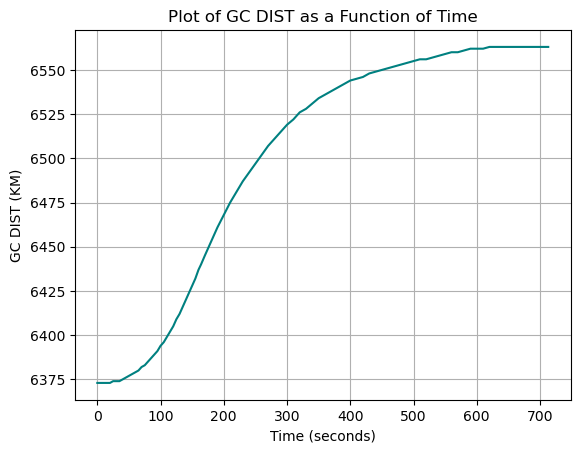

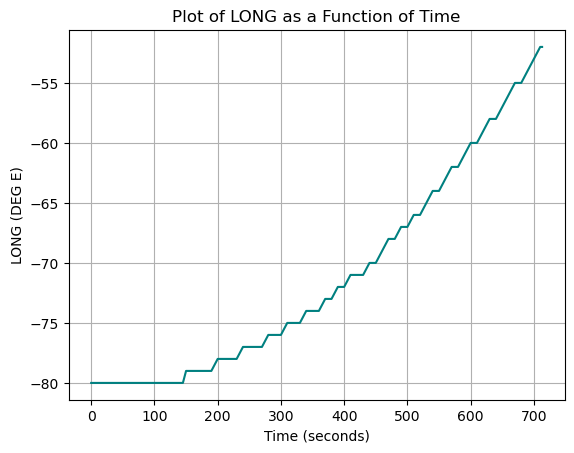

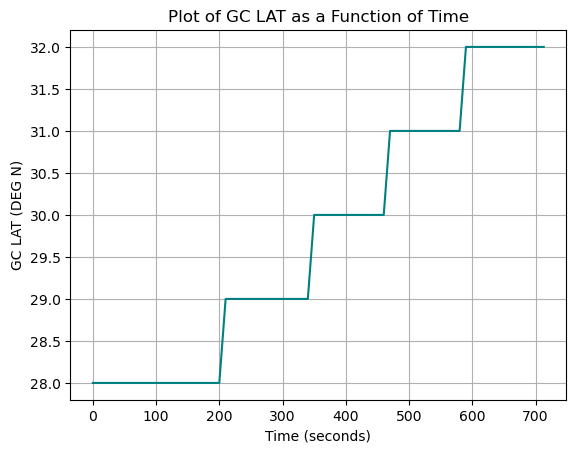

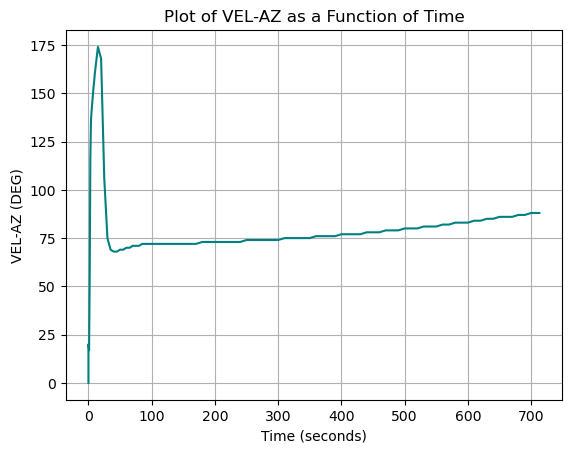

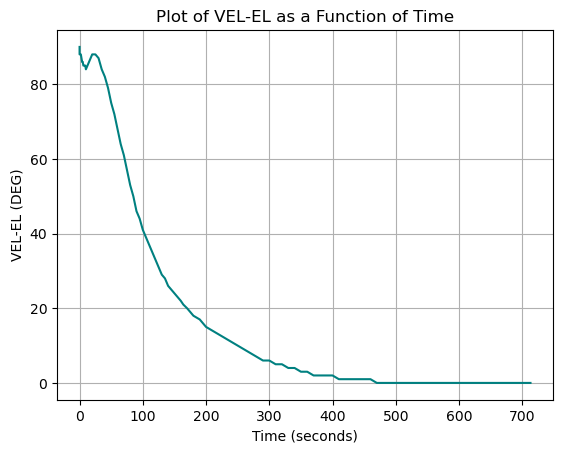

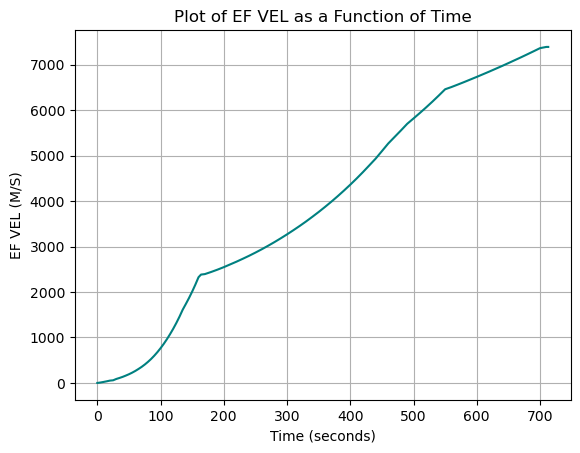

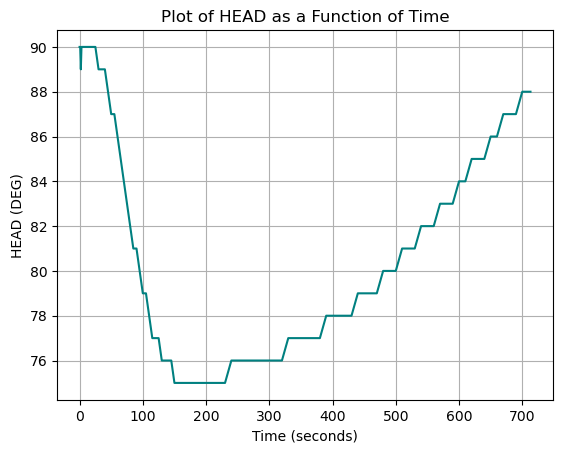

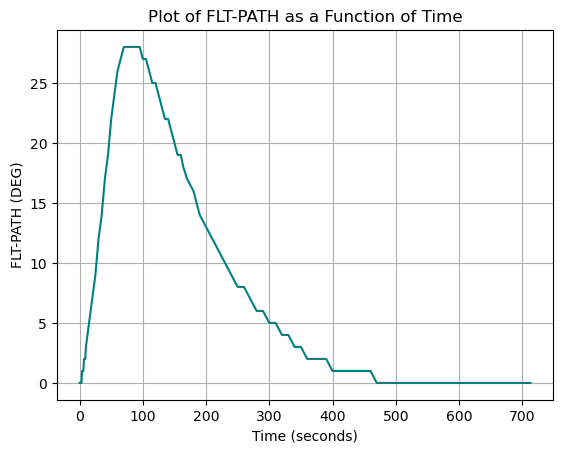

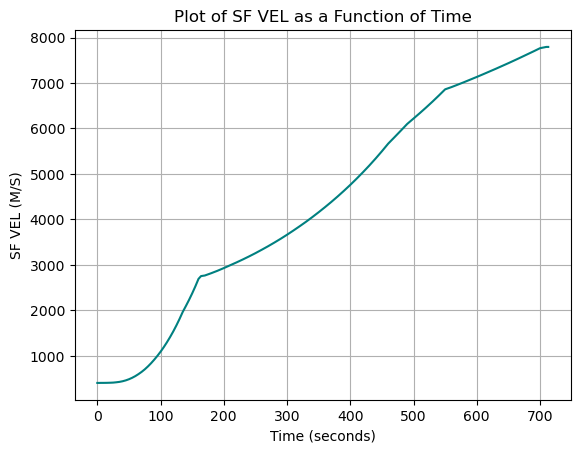

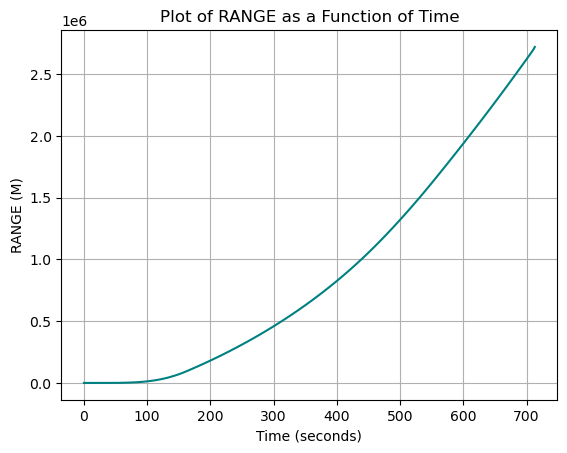

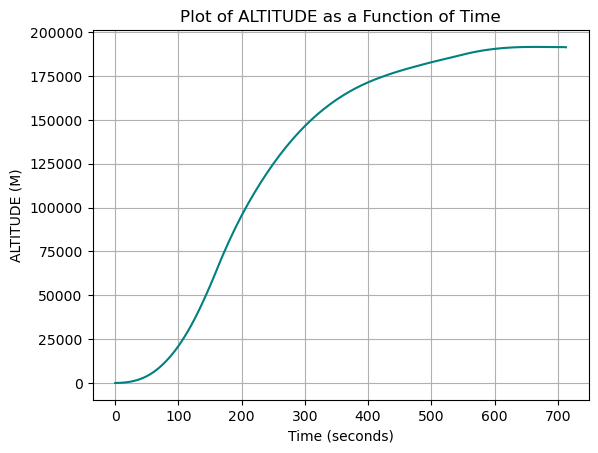

In [61]:
#making 11 graphs 
for i in range(1, len(headers)):
    plt.title("Plot of "+ headers[i] + " as a Function of Time")
    plt.xlabel("Time (seconds)")
    plt.ylabel(headers[i]+" ("+units[i]+')')
    plt.plot(Apollo[headers[0]], Apollo[headers[i]], color="teal")
    plt.grid(True)
    plt.show()

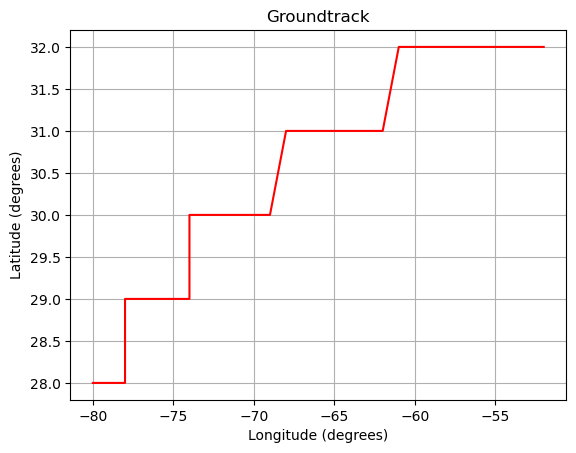

In [63]:
#groundtrack plot 
plt.title("Groundtrack")
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.grid(True)
plt.plot(Apollo["LONG"], Apollo["GC LAT"], color='red')
plt.show()

Text(0.5, 1.0, 'Map of Trajectory of Apollo 10')

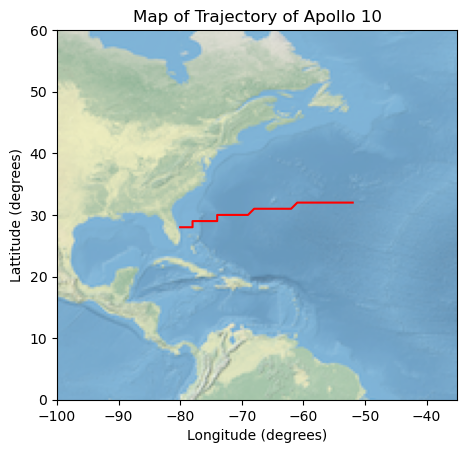

In [88]:
#uploading map 
pic = plt.imread("maps/NE1_50M_SR_W_1080.png")
fig, ax = plt.subplots()
ax.imshow(pic, extent=[-180, 180, -90, 90])
ax.plot(Apollo["LONG"], Apollo["GC LAT"], color='red', label="Groundtrack of Apollo 10")
ax.set_xlim(-100, -35)
ax.set_ylim(0, 60)
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Lattitude (degrees)")
ax.set_title("Map of Trajectory of Apollo 10")

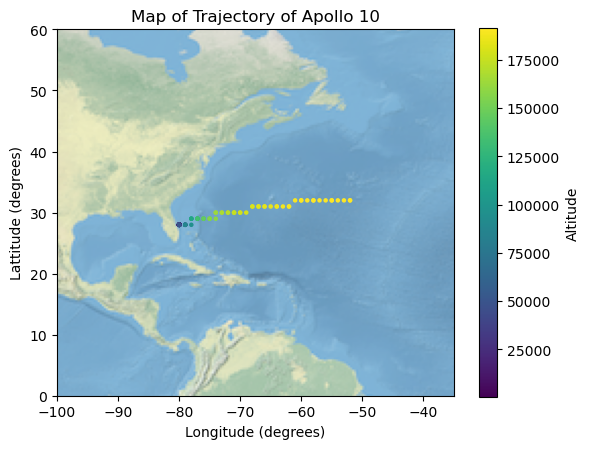

In [94]:
pic = plt.imread("maps/NE1_50M_SR_W_1080.png")
fig, ax = plt.subplots()
ax.imshow(pic, extent=[-180, 180, -90, 90])
ax.set_xlim(-100, -35)
ax.set_ylim(0, 60)
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Lattitude (degrees)")
ax.set_title("Map of Trajectory of Apollo 10")
scatter = ax.scatter(Apollo["LONG"], Apollo["GC LAT"], c=Apollo["ALTITUDE"], s=5)
plt.colorbar(scatter, label="Altitude")